Connecting to SAP Database...
✅ Connection Successful!
Running SQL Query...


/var/folders/gj/kxtzfhl92x14t11d2_cs14hh0000gn/T/ipykernel_72088/1426633013.py:68: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


✅ Data Loaded! Found 10 rows.


/var/folders/gj/kxtzfhl92x14t11d2_cs14hh0000gn/T/ipykernel_72088/1426633013.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(
/var/folders/gj/kxtzfhl92x14t11d2_cs14hh0000gn/T/ipykernel_72088/1426633013.py:95: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
/Users/dp/Library/CloudStorage/GoogleDrive-drenzo@bigtimeempire.com/Shared drives/IT Team/SAP/BEC/Project AYOS - SAP Reimplementation 2025/SAP Data Projects - Drenzo/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


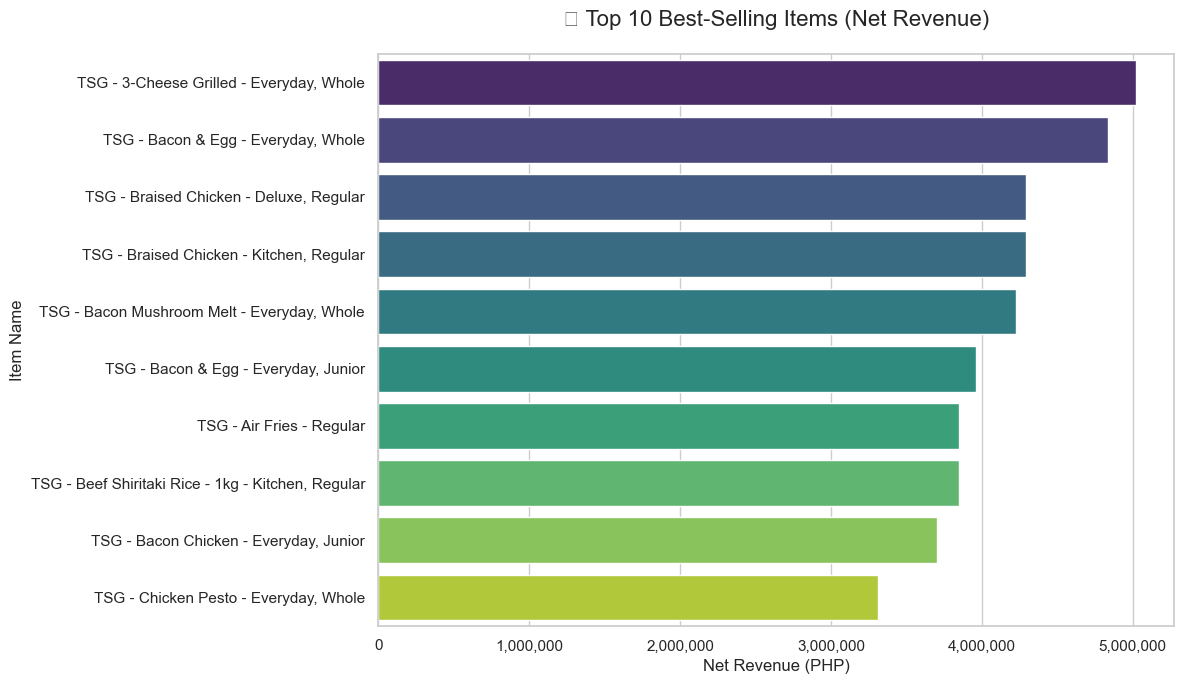

In [2]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import credentials as creds  # This imports your sensitive info safely

# ==========================================
# 1. CONNECT TO MS SQL SERVER
# ==========================================
print("Connecting to SAP Database...")

conn_str = (
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={creds.SERVER};"
    f"DATABASE={creds.DATABASE};"
    f"UID={creds.USER};"
    f"PWD={creds.PASSWORD};"
    "Encrypt=no;"
    "TrustServerCertificate=yes;"
)

try:
    conn = pyodbc.connect(conn_str)
    print("✅ Connection Successful!")
except Exception as e:
    print(f"❌ Connection Failed: {e}")
    exit()

# ==========================================
# 2. THE ANALYST QUERY
# ==========================================
# Strategy: 
# We need 'Net Revenue'. This means we take positive Sales (OINV) 
# and subtract returns/credit memos (ORIN).
# The SQL does the heavy lifting (Aggregation) so Python receives a clean summary.

sql = """
SELECT TOP 10
    Items.Dscription,
    SUM(Items.LineTotal) as NetRevenue
FROM (
    -- 1. Get All Invoices (Positives)
    SELECT T1.Dscription, T1.LineTotal
    FROM OINV T0
    INNER JOIN INV1 T1 ON T0.DocEntry = T1.DocEntry
    WHERE T0.DocDate >= '2024-01-01' 
      AND T0.CANCELED = 'N'

    UNION ALL

    -- 2. Get All Credit Memos (Negatives)
    -- We multiply by -1 so it subtracts from the total
    SELECT T1.Dscription, -T1.LineTotal
    FROM ORIN T0
    INNER JOIN RIN1 T1 ON T0.DocEntry = T1.DocEntry
    WHERE T0.DocDate >= '2024-01-01' 
      AND T0.CANCELED = 'N'
) AS Items
GROUP BY Items.Dscription
ORDER BY NetRevenue DESC
"""

# ==========================================
# 3. FETCH DATA
# ==========================================
print("Running SQL Query...")
df = pd.read_sql(sql, conn)
conn.close() 
print(f"✅ Data Loaded! Found {len(df)} rows.")

# ==========================================
# 4. VISUALIZE
# ==========================================
plt.figure(figsize=(12, 7))  # Set canvas size (Width, Height)
sns.set_theme(style="whitegrid")

# Create Bar Chart
# Note: x="NetRevenue" matches the SQL alias above
chart = sns.barplot(
    data=df,
    x="NetRevenue",       
    y="Dscription",
    palette="viridis"
)

# --- Formatting ---
plt.title("🏆 Top 10 Best-Selling Items (Net Revenue)", fontsize=16, pad=20)
plt.xlabel("Net Revenue (PHP)", fontsize=12)
plt.ylabel("Item Name", fontsize=12)

# Format the X-axis to show commas (e.g., 1,500,000)
chart.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()